### Longest Repeating Character Replacement

- You are given a string s consisting of only `uppercase english characters and an integer k`.
- You can choose `up to k characters` of the string and replace them with any other uppercase English character.

- After performing at most k replacements, return the length of the longest substring which contains only one distinct character.

### Example 1:

Input: s = "XYYX", k = 2

Output: 4
Explanation: Either replace the 'X's with 'Y's, or replace the 'Y's with 'X's.

### Example 2:

Input: s = "AAABABB", k = 1

Output: 5

### Constraints:

- 1 <= s.length <= 1000
- 0 <= k <= s.length



### Problem analysis

- you can choose any character of the string and change it to any other uppercase English Character.
    - input will only be uppercase English character  
    - we are allowed to replace k diff characters in the string
    - we gonna  return the longest substring containing the same letter we can get after performing k diff replacements
    - we just need the length, we dont need to make the replacements in the input string
   

- we will learn how to solve this in O(26*n)
- O(n) is tricky so we will go with above complexity

- Brute force
    - check every single substring
    - there are n**2 substrings , not most efficient

- res=> longest substring that contains a single character and we can make upto two replacements
- 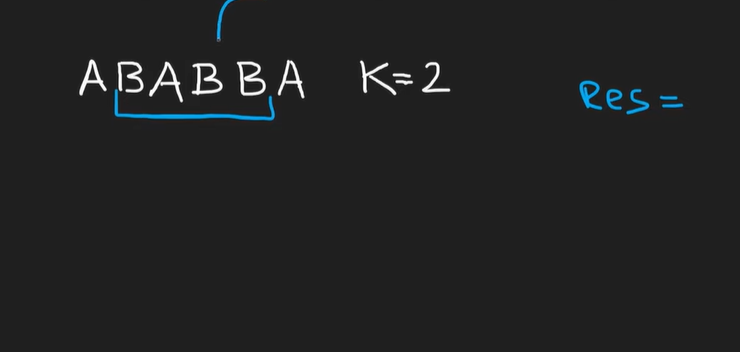
- take the above example, how do we know that if the substring is valid?
    - do we need to replace B or A?
    - ofcourse the char that occurs less frequently
    - `we want all characters in a particular window to match the most common char in that window`

- we gonna create a hashmap of array that takes every single character in a given substring and count the occurence of each character
- we gonna take the length of the window and subtract the   the count of the most freq char 
    - this gonna tell us the no of char in our window that needs to be replaced.  
    - 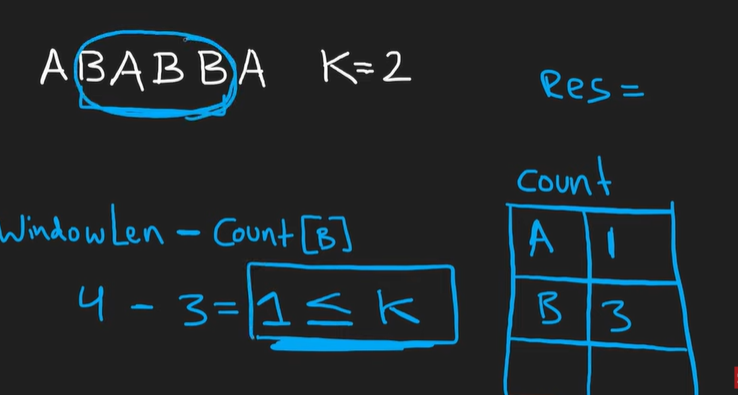
     
- `next question  ,how we know which char is the most frequent?`
    - brute force is to look at the hashmap, as we know that the keys are going to be only max of 26
    - finding the max char is O(26). bit more inefficient but since we are technically linear time,its fine.
-   we need to add a sliding window technique
    - we gonna take our window
    -   start at the beginning, expand it as long as we can until the condition is valid if not, then move left until the string becomes valid once again.
- initially left and right are gonna be at beginning and count of all the chars will be 0
- `size[window] - count(most freq char in window)<=k`
- size of window=`R-L`


## Aliter
    - we gonna have a variable `maxFreq` - count of most freq char at any given time, 


In [ ]:
class Solution:
    def characterReplacement(self, s: str, k: int) -> int:
        count={}
        res=0
        l=0
       
        for r in range(len(s)):
            count[s[r]]= 1+count.get(s[r],0)
            while (r-l+1)-max(count.values())>k:
                count[s[l]]-=1
                l+=1
            res=max(res,r-l+1)
        return res


# count,l,res set them up
# for r in range(len(s)):
    # increase the count of s[r]
    # while r-l+1-max(count.values())>k:
    #    increment l
    #    decrement count of l 
    # res=max(res,window)
# return res 